# Language Translation Using Transformer

This notebook is to build a Seq2Seq language translator using transformer architecure. 
We follows the content from:
* The medium post [Building a Seq2Seq Transformer Model for Language Translation: A Comprehensive Guide](https://ravjot03.medium.com/building-a-seq2seq-transformer-model-for-language-translation-a-comprehensive-guide-875bb7947ee6).
* The [jupyter notebook](https://github.com/Ravjot03/Transformer-Based-Text-Translation/blob/main/Transformer_Text_Translation_ENG_GER.ipynb) from the post author.

## Other Reference

* [A detailed guide to Pytorch’s nn.Transformer() module](https://towardsdatascience.com/a-detailed-guide-to-pytorchs-nn-transformer-module-c80afbc9ffb1/) explains details transformer code structure.
* [Building a Transformer Model for Language Translation](https://machinelearningmastery.com/building-a-transformer-model-for-language-translation/)

![transformer_translator](./images/translator_arch.png)

## Summary of the Mapping (Explanation From Gemini)

When you run the training loop in that notebook, here is how the variables map to the Q, K, V concepts:
* Query ($Q$): Comes from tgt (the German tokens). The model asks: "Given the German words I have so far, what should I look for in the English text?"
* Key ($K$): Comes from memory (the English tokens). These act as the "index" or "labels" for the English information.
* Value ($V$): Also comes from memory. This is the actual "meaning" or "content" of the English words that gets pulled into the German side.

![translation_example](./images/seq2seq_example.png)

In [1]:
!pip install torchtext==0.15.1

In [2]:
import torch
import torch.nn as nn
from torch import Tensor

# from torch.nn import Transformer
from embedding_helper import (
    TokenEmbedding,
    PositionalEncoding,
)
from data_helper import (
    collate_fn,
    create_mask,
    get_translation_data,
    generate_square_subsequent_mask,
    text_transform,
    BOS_IDX,
    EOS_IDX,
    PAD_IDX,
)

token_transform, vocab_transform = get_translation_data()

## Seq2Seq Transformer Network

In [3]:
# Seq2Seq Network
class Transformer(nn.Module):
    def __init__(self,
                 num_encoder_layers: int,
                 num_decoder_layers: int,
                 emb_size: int,
                 nhead: int,
                 src_vocab_size: int, # source vocab
                 tgt_vocab_size: int, # target vocab
                 dim_feedforward: int = 512,
                 dropout: float = 0.1):
        super().__init__()
        self.src_tok_emb = TokenEmbedding(src_vocab_size, emb_size)
        self.tgt_tok_emb = TokenEmbedding(tgt_vocab_size, emb_size)
        self.positional_encoding = PositionalEncoding(emb_size, max_len=5000, dropout=dropout)
        self.transformer = nn.Transformer(d_model=emb_size,
                                          nhead=nhead,
                                          num_encoder_layers=num_encoder_layers,
                                          num_decoder_layers=num_decoder_layers,
                                          dim_feedforward=dim_feedforward,
                                          dropout=dropout)
        self.generator = nn.Linear(emb_size, tgt_vocab_size)

    def forward(self,
                src: Tensor,
                trg: Tensor,
                src_mask: Tensor,
                tgt_mask: Tensor,
                src_padding_mask: Tensor,
                tgt_padding_mask: Tensor,
                memory_key_padding_mask: Tensor):
        """
        Defintion: https://docs.pytorch.org/docs/stable/generated/torch.nn.Transformer.html
        
            * src (Tensor) – the sequence to the encoder (required).
            * tgt (Tensor) – the sequence to the decoder (required).
            * src_mask (Tensor | None) – the additive mask for the src sequence (optional).
            * tgt_mask (Tensor | None) – the additive mask for the tgt sequence (optional).
            * memory_mask (Tensor | None) – the additive mask for the encoder output (optional).
            * src_padding_mask (Tensor | None) – the Tensor mask for src keys per batch (optional).
            * tgt_padding_mask (Tensor | None) – the Tensor mask for tgt keys per batch (optional).
            * memory_key_padding_mask (Tensor | None) – the Tensor mask for memory keys per batch (optional).
        """
        
        src_emb = self.positional_encoding(self.src_tok_emb(src))
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(trg))
        
        outs = self.transformer(src_emb, tgt_emb, src_mask, tgt_mask, None,
                                src_padding_mask, tgt_padding_mask, memory_key_padding_mask)
        return self.generator(outs)

    def encode(self, src: Tensor, src_mask: Tensor):
        return self.transformer.encoder(self.positional_encoding(self.src_tok_emb(src)), src_mask)

    def decode(self, tgt: Tensor, memory: Tensor, tgt_mask: Tensor):
        """
        Here memory plays a role like 
        memory = self.transformer.encoder(self.positional_encoding(self.src_tok_emb(src)), src_mask)
        """
        return self.transformer.decoder(self.positional_encoding(self.tgt_tok_emb(tgt)), memory, tgt_mask)

In [4]:
!pip install "numpy<2"

In [5]:
torch.manual_seed(0)

SRC_LANGUAGE = 'en'
TGT_LANGUAGE = 'de'

SRC_VOCAB_SIZE = len(vocab_transform[SRC_LANGUAGE])
TGT_VOCAB_SIZE = len(vocab_transform[TGT_LANGUAGE])

print(f"source vocab size: {SRC_VOCAB_SIZE}, target vocab size: {TGT_VOCAB_SIZE}")

emb_size = 512
nhead = 8
ffn_hid_dim = 512
BATCH_SIZE = 128
num_encoder_layers = 3
num_decoder_layers = 3

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

source vocab size: 10837, target vocab size: 19214


## Train Model

In [6]:
transformer = Transformer(num_encoder_layers, num_decoder_layers, emb_size,
                          nhead, SRC_VOCAB_SIZE, TGT_VOCAB_SIZE, ffn_hid_dim)

for p in transformer.parameters():
    if p.dim() > 1:
        nn.init.xavier_uniform_(p)

model = transformer.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)
loss_fn = torch.nn.CrossEntropyLoss(ignore_index=PAD_IDX)

In [7]:
from torchtext.datasets import multi30k, Multi30k
from torch.utils.data import DataLoader

multi30k.URL["train"] = "https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/Multi30k/training.tar.gz"
multi30k.URL["valid"] = "https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/Multi30k/validation.tar.gz"

def train_one_epoch(model, optimizer):
    model.train()
    losses = 0
    num_batches = 0  # Track the number of batches manually
    
    train_iter = Multi30k(split='train', language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
    train_dataloader = DataLoader(train_iter, batch_size=BATCH_SIZE, collate_fn=collate_fn)

    for src, tgt in train_dataloader:
        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)

        tgt_input = tgt[:-1, :]

        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input)

        logits = model(src, tgt_input, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask, src_padding_mask)

        optimizer.zero_grad()

        tgt_out = tgt[1:, :]
        loss = loss_fn(logits.reshape(-1, logits.shape[-1]), tgt_out.reshape(-1))
        loss.backward()

        optimizer.step()
        losses += loss.item()
        num_batches += 1

    avg_loss = losses / num_batches
    return avg_loss


def evaluate(model):
    model.eval()
    losses = 0
    num_batches = 0  # Track the number of batches manually

    val_iter = Multi30k(split='valid', language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
    val_dataloader = DataLoader(val_iter, batch_size=BATCH_SIZE, collate_fn=collate_fn)

    for src, tgt in val_dataloader:
        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)

        tgt_input = tgt[:-1, :]

        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input)

        logits = model(src, tgt_input, src_mask, tgt_mask,src_padding_mask, tgt_padding_mask, src_padding_mask)

        tgt_out = tgt[1:, :]
        loss = loss_fn(logits.reshape(-1, logits.shape[-1]), tgt_out.reshape(-1))
        losses += loss.item()
        num_batches += 1

    avg_loss = losses / num_batches
    return avg_loss

## Run 50 Epochs

In [9]:
num_epochs = 50

train_losses, val_losses = [], []
for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(transformer, optimizer)
    val_loss = evaluate(transformer)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch: {epoch}, Train loss: {train_loss:.3f}, Val loss: {val_loss:.3f}")


Epoch: 1, Train loss: 4.737, Val loss: 4.186
Epoch: 2, Train loss: 3.798, Val loss: 3.553
Epoch: 3, Train loss: 3.263, Val loss: 3.187
Epoch: 4, Train loss: 2.881, Val loss: 2.911
Epoch: 5, Train loss: 2.588, Val loss: 2.732
Epoch: 6, Train loss: 2.351, Val loss: 2.595
Epoch: 7, Train loss: 2.153, Val loss: 2.463
Epoch: 8, Train loss: 1.989, Val loss: 2.341
Epoch: 9, Train loss: 1.846, Val loss: 2.251
Epoch: 10, Train loss: 1.717, Val loss: 2.196
Epoch: 11, Train loss: 1.607, Val loss: 2.168
Epoch: 12, Train loss: 1.505, Val loss: 2.132
Epoch: 13, Train loss: 1.411, Val loss: 2.083
Epoch: 14, Train loss: 1.324, Val loss: 2.064
Epoch: 15, Train loss: 1.246, Val loss: 2.030
Epoch: 16, Train loss: 1.176, Val loss: 2.037
Epoch: 17, Train loss: 1.108, Val loss: 2.053
Epoch: 18, Train loss: 1.046, Val loss: 2.034
Epoch: 19, Train loss: 0.984, Val loss: 2.029
Epoch: 20, Train loss: 0.926, Val loss: 2.025
Epoch: 21, Train loss: 0.874, Val loss: 2.021
Epoch: 22, Train loss: 0.824, Val loss: 2.0

In [16]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 18.5 MB/s  0:00:00 eta 0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 22.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib] 5/6 [matplotlib]ourpy]


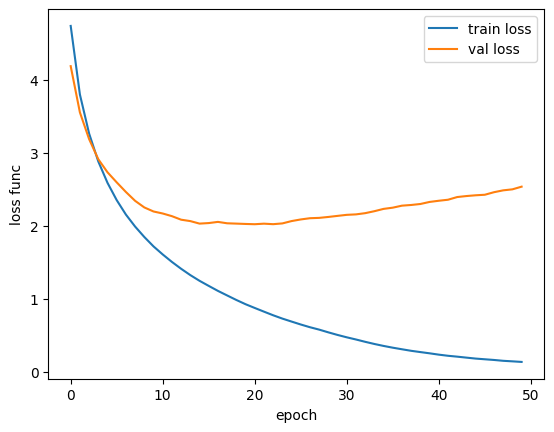

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(range(len(train_losses)), train_losses, label="train loss")
plt.plot(range(len(val_losses)), val_losses, label="val loss")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("loss func")
plt.show()

The best val loss is around epoch = 15-20. Thus we can early stop.

## Evaluate Translation

In [10]:
# function to generate output sequence using greedy algorithm
def greedy_decode(model, src, src_mask, max_len, start_symbol):
    src = src.to(DEVICE)
    src_mask = src_mask.to(DEVICE)

    memory = model.encode(src, src_mask)
    ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(DEVICE)
    for i in range(max_len-1):
        memory = memory.to(DEVICE)
        tgt_mask = (generate_square_subsequent_mask(ys.size(0))
                    .type(torch.bool)).to(DEVICE)
        out = model.decode(ys, memory, tgt_mask)
        out = out.transpose(0, 1)
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item()

        ys = torch.cat([ys,
                        torch.ones(1, 1).type_as(src.data).fill_(next_word)], dim=0)
        if next_word == EOS_IDX:
            break
    return ys

    
def translate(model: torch.nn.Module, src_sentence: str):
    model.eval()
    src = text_transform[SRC_LANGUAGE](src_sentence).view(-1, 1)
    num_tokens = src.shape[0]
    print(num_tokens)
    src_mask = (torch.zeros(num_tokens, num_tokens)).type(torch.bool)
    tgt_tokens = greedy_decode(
        model,  src, src_mask, max_len=num_tokens + 5, start_symbol=BOS_IDX).flatten()
    return " ".join(vocab_transform[TGT_LANGUAGE].lookup_tokens(list(tgt_tokens.cpu().tolist()))).replace("<bos>", "").replace("<eos>", "")


In [11]:
print(translate(transformer, "A group of people stand in an igloo"))

10
 Eine Gruppe von Personen steht in einem Iglu . 


In [12]:
print(translate(transformer, "The cat is sleeping"))

6
 Die Katze schläft auf der Katze . 


In [13]:
print(translate(transformer, "The cat is sitting by the window"))

9
 Die Katze sitzt am Fenster . 
